### This is the script to do normal NLP analysis for climate risk disclosure

Notice: You should only run this after running '1-explatorary_analysis.ipynb'. And this one only use nltk the normal NLP analysis type

In [ ]:
# Download installer from https://github.com/UB-Mannheim/tesseract/wiki
# Install v5.x, then verify by running on CMD: tesseract --version

In [ ]:
#!pip install nltk
#!pip install PyPDF2
#!pip install PymuPDF
#!pip install pytesseract

In [5]:
import ast, re, time, os, requests
import io
import pandas as pd
import numpy as np
from datetime import date
import seaborn as sns 
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import textwrap
#NLTK Imports
import nltk 
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
#Data processing import 
import fitz  # pymupdf
#import pytesseract
from PIL import Image
from pathlib import Path

np.NaN = np.nan

nltk.download('vader_lexicon')
nltk.download('stopwords')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\QuyenN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# Point to new Tesseract installation file if needed
# Tesseract need to be at least version 5.x
#import pytesseract
#import os
#os.environ['TESSDATA_PREFIX'] = r'C:\Program Files\Tesseract-OCR\tessdata'
#pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
# Verify version from Python
#pytesseract.get_tesseract_version()

In [6]:
# Output folder for CSVs and PDFs — update if running on a different machine
FOLDER     = r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure'
ANALYSIS_FOLDER =  r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026'  
FIG_FOLDER =  r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026\figures'  
TABLE_FOLDER =  r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026\tables'  

PDF_FOLDER = os.path.join(FOLDER, 'pdfs_2026','pdfs')


### First, explode the file into multipel pdf file

In [9]:
disclose_2026 = pd.read_csv(os.path.join(ANALYSIS_FOLDER, 'List_of_all_disclosures_as_of_2026_mapped.csv'))
#Explore 
disclose_2026['pdf_files'] = disclose_2026['pdf_files'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

disclose_2026_exploded = (
    disclose_2026
    .explode('pdf_files')
    .dropna(subset=['pdf_files'])
    .reset_index(drop=True)
)


print(f'The number of disclosure is {disclose_2026.shape[0]}')
print(f'The number of disclosed PDF is {disclose_2026_exploded.shape[0]}')
#Then remove those without file
disclose_2026_exploded =disclose_2026_exploded[(disclose_2026_exploded['pdf_count']>0) ]
print(f'The number of disclosed PDF after remove those with 0 is {disclose_2026_exploded.shape[0]}')
# Then remove those with investment schemes 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Type']!='Investment schemes']
print(f'The number of disclosed PDF for normal firms is {disclose_2026_exploded.shape[0]}')
# Then remove those in 2026 cohort 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['Cohort']!='Cohort 3 (Jul 2025 – Jun 2026)']
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
disclose_2026_exploded.to_csv(os.path.join(FIG_FOLDER, 'List_of_all_PDF_for_normal_companies.csv'))
# Then I have use a manual selection of PDF to be included
included_pdf = pd.read_csv(os.path.join(ANALYSIS_FOLDER, 'interim_results\Included_PDF_only.csv'))
disclose_2026_exploded = pd.merge(disclose_2026_exploded,
                                  included_pdf,
                                  how = 'left',
                                  left_on = ['Company_Scheme', 'Cohort','pdf_files'],
                                  right_on =['Company_Scheme', 'Cohort','pdf_files'] )
disclose_2026_exploded = disclose_2026_exploded.drop_duplicates(subset = ['pdf_files'])
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded['FinalInclusion'] ==1]
# Rename investment schemes into Finance other 
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Investment Schemes',
    'Finance - Other',
    disclose_2026_exploded['Industry']
)
disclose_2026_exploded['Industry'] = np.where(
    disclose_2026_exploded['Industry'] == 'Other (Industrials, Consumer, Tech, Transport, etc.)',
    'Other industries',
    disclose_2026_exploded['Industry']
)
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
#Remove one file 
disclose_2026_exploded = disclose_2026_exploded[disclose_2026_exploded["pdf_files"]!="CRD 2023 CEO Declaration.pdf"]
print(f'The number of disclosed PDF for normal firms in 2024-2025 is {disclose_2026_exploded.shape[0]}')
disclose_2026_exploded.to_csv(os.path.join(ANALYSIS_FOLDER, 'interim_results\List_of_selected_PDF_forLLManalysis.csv'))


The number of disclosure is 743
The number of disclosed PDF is 3206
The number of disclosed PDF after remove those with 0 is 3206
The number of disclosed PDF for normal firms is 410
The number of disclosed PDF for normal firms in 2024-2025 is 410
The number of disclosed PDF for normal firms in 2024-2025 is 235
The number of disclosed PDF for normal firms in 2024-2025 is 234


<>:28: SyntaxWarning: invalid escape sequence '\I'
<>:51: SyntaxWarning: invalid escape sequence '\L'
<>:28: SyntaxWarning: invalid escape sequence '\I'
<>:51: SyntaxWarning: invalid escape sequence '\L'
C:\Users\QuyenN\AppData\Local\Temp\ipykernel_37188\417294728.py:28: SyntaxWarning: invalid escape sequence '\I'
  included_pdf = pd.read_csv(os.path.join(ANALYSIS_FOLDER, 'interim_results\Included_PDF_only.csv'))
C:\Users\QuyenN\AppData\Local\Temp\ipykernel_37188\417294728.py:51: SyntaxWarning: invalid escape sequence '\L'
  disclose_2026_exploded.to_csv(os.path.join(ANALYSIS_FOLDER, 'interim_results\List_of_selected_PDF_forLLManalysis.csv'))


In [10]:
# ---- EXCLUDE specific company-year combinations ----
exclude_list = [
    ("ANZ GROUP HOLDINGS LIMITED", 2024),
    ("HENDERSON FAR EAST INCOME LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2024),
    ("INSURANCE AUSTRALIA GROUP LIMITED", 2025),
    ("THE BANKERS INVESTMENT TRUST PLC", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2024),
    ("WORKS FINANCE (NZ) LIMITED", 2025),
]

exclude_set = set(exclude_list)

disclose_2026_exploded = disclose_2026_exploded[
    ~disclose_2026_exploded.apply(
        lambda r: (r['Company Name'], r['period_year']) in exclude_set,
        axis=1
    )
]
print(f'Company-year groups to process after exclusion: {len(disclose_2026_exploded)}')

Company-year groups to process after exclusion: 227


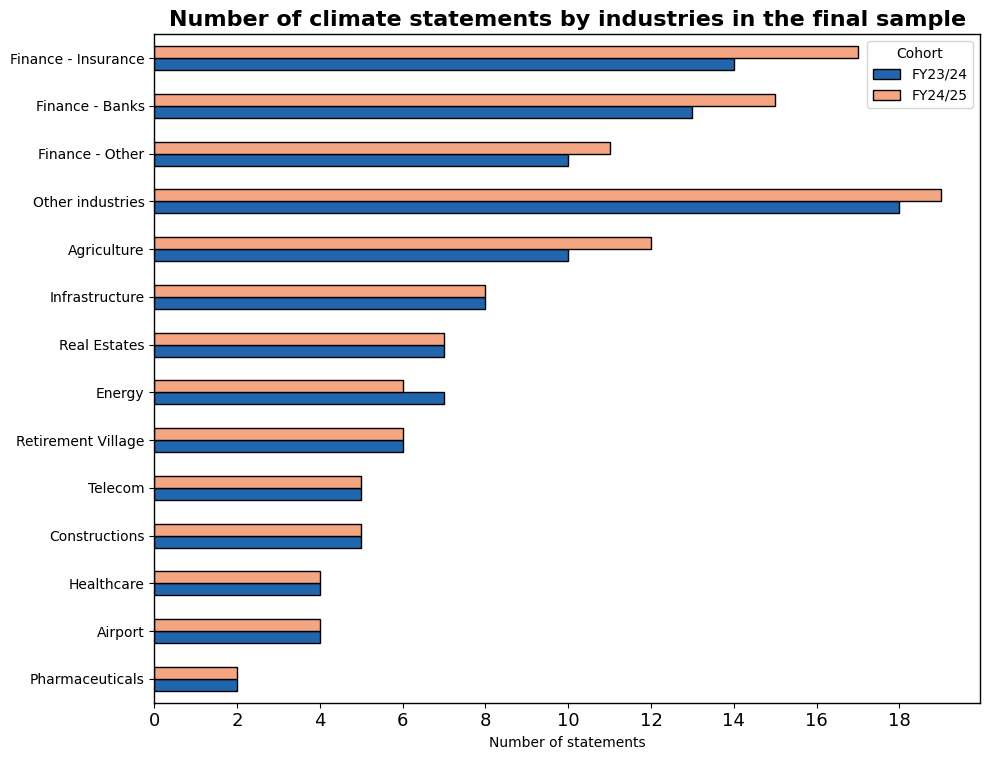

In [ ]:
### Breakdown by industry — Finance vs Non-Finance grouped
import textwrap

finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other']

pivot_table = disclose_2026_exploded.pivot_table(
    index='Industry', columns='Cohort', values='Company_Scheme', aggfunc='count'
)

# Sort each group by total (ascending → largest at top in barh)
def sort_by_total(df, idx):
    sub = df.loc[[i for i in idx if i in df.index]]
    return sub.loc[sub.sum(axis=1).sort_values().index].index.tolist()

fin_idx      = [i for i in pivot_table.index if i in finance_industries]
other_idx    = [i for i in pivot_table.index if i not in finance_industries]
fin_sorted   = sort_by_total(pivot_table, fin_idx)
other_sorted = sort_by_total(pivot_table, other_idx)

# Non-Finance at bottom, Finance at top
pivot_table = pivot_table.loc[other_sorted + fin_sorted]

n_other   = len(other_sorted)
n_finance = len(fin_sorted)
n_total   = len(pivot_table)


COHORT_COLORS = {'FY23/24': '#2166AC', 'FY24/25': '#F4A582'}
colors = [COHORT_COLORS[c] for c in pivot_table.columns]

fig, ax = plt.subplots(figsize=(10, max(4, n_total * 0.55)))
pivot_table.plot(kind='barh', stacked=False, ax=ax, color=colors,
                 edgecolor='black')
ax.grid(visible=False)
ax.tick_params(axis='x', labelsize=13)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(f'Number of climate statements by industries in the final sample (n = {disclose_2026_exploded.shape[0]})', fontweight='bold', fontsize=16)
ax.set_xlabel('Number of statements')
ax.set_ylabel('')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig04_disclosure_overtime_by_industry.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Now, let us define functions to run the NLP analysis 

In [12]:
#sentiment
sent = SentimentIntensityAnalyzer()
st = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


## climate hazard datasets key words
drought = ['drought', 'severe drought', 'dry', 'SPI', 'standardised precipitation index', 'standardized precipitation index', 'rainfall', '10 minute average', 'topography']
winds= ['wind', 'extreme winds', 'cyclone','tsunami']
rainfall =['rain','pluvial','pluvial flooding','rainfall']
river = ['river','flood', 'river flooding', 'fluvial',
         'daily rainfall', 'river level', 'flow', 'soils', 'vegetation', 
        ]
coastal = ['coastal','flood','topography',  'sea-level', 'sea level', 'esl', 'extreme sea',
           'coastal flooding', 'inundation', 'groundwater','nearshore', 'bathymetry', 'bathymetric']
shoreline_change = ['shoreline change','aerial', 'aerial photography', 'historical aerial', 'topography', 'soils', 'soil', 'geology']
heatwave = ['heatwave', 'extreme temperature', 'humidity', 'rainfall', 'extreme heat', 'heat']
landslide =['landslide', 'soil', ' soil erosion', 'erosion', 'topography', 'geology', 'soils', 'vegetation', 'rainfall']
other = ['extreme event', 'extreme heat','extreme sea','extreme winds', 'disaster']
emissions = ['emission', 'carbon', 'ghg','greenhouse','methane',' ets ']
gns_related_words = [' gns', 'merit', 'riskscape','nigem','nz searise', 'groundwater', 'antarctica']
niwa_words = [' niwa']
## put climate hazards into a list to easily loop over
keywords= drought +  winds +  river +  coastal +  shoreline_change +  heatwave +  landslide + other + emissions + other +gns_related_words +niwa_words

In [ ]:
# A function to get page text 
def _extract_pages(pdf_path: str) -> list[dict]:
    """Extract text page by page from a PDF.

    Direct text extraction via pymupdf is always performed first. Any image
    blocks found on the page are additionally passed through Tesseract OCR
    and their text is appended — this catches text embedded in figures,
    charts, and scanned inserts regardless of how much regular text the
    page already has.
    """
    pages = []
    doc = fitz.open(pdf_path)

    for page_num, page in enumerate(doc):
        text = page.get_text().strip()

        for img in page.get_images(full=True):
            xref = img[0]
            base_image = doc.extract_image(xref)
            image = Image.open(io.BytesIO(base_image["image"]))
            ocr_text = pytesseract.image_to_string(image).strip()
            if ocr_text:
                text += "\n" + ocr_text

        if text:
            pages.append({
                "text": text,
                "page": page_num,
                "source": Path(pdf_path).name,
            })

    doc.close()
    return pages
    
# Clean data 
def clean_data(text):
    # change to lower and remove spaces on either side
    text =  text.lower().strip() 

    # remove extra spaces in between
    text = re.sub(' +', ' ', text)

    # remove punctuation
    text= re.sub('[^a-zA-Z]', ' ', text)

    # remove stopwords and get the stem
    text =  ' '.join(st.stem(x) for x in text.split() if x not in stop_words)
    return text

In [13]:
disclose_2026_exploded.head()

,Unnamed: 0,Company Name,PeriodText,Type,Investment Scheme Name,status,period_year,Company_Scheme,PeriodDate,Analysed_2024,Status,Cohort,pdf_files,pdf_count,no_pdf,Industry,Types,FinalInclusion
0,0,AA INSURANCE LIMITED,30-06-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AA INSURANCE LIMITED,2025-06-30,NaN,Submitted,FY24/25,AA Insurance 2025 Climate Statement FINAL SIGN...,2,0,Finance - Insurance,Normal companies,1.0
2,1,AA INSURANCE LIMITED,30-06-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AA INSURANCE LIMITED,2024-06-30,NaN,Submitted,FY23/24,AA Insurance 2024 Climate Statements.pdf,1,0,Finance - Insurance,Normal companies,1.0
3,2,AFT PHARMACEUTICALS LIMITED,31-03-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AFT PHARMACEUTICALS LIMITED,2024-03-31,NaN,Submitted,FY23/24,240523 FY2024 Annual Report.pdf,2,0,Pharmaceuticals,Normal companies,1.0
5,3,AFT PHARMACEUTICALS LIMITED,31-03-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AFT PHARMACEUTICALS LIMITED,2025-03-31,NaN,Submitted,FY24/25,250522 AFT FY25 Annual Report.pdf,1,0,Pharmaceuticals,Normal companies,1.0
6,5,AIA NEW ZEALAND LIMITED,31-12-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AIA NEW ZEALAND LIMITED,2024-12-31,NaN,Submitted,FY24/25,AIA NZ Group Annual Report Dec-2024 FINAL_stam...,1,0,Finance - Insurance,Normal companies,1.0


In [45]:
#Simple analysis 
nlp_analysis = pd.DataFrame()
for i,row  in disclose_2026_exploded.iterrows():
    pdf_file = row['pdf_files']
    company = row['Company Name']
    period_year = row['period_year']
    period = row['PeriodDate']
    industry = row['Industry']
    cohort = row['Cohort']
    #Get safe name 
    safe_name = re.sub(r'[^\w\s-]', '', company)[:50].strip().replace(' ', '_') + f"_{period_year}"
    company_folder = os.path.join(PDF_FOLDER, safe_name)
    pdfs = glob.glob(os.path.join(company_folder, '*.pdf'))
    filename = os.path.join(PDF_FOLDER, safe_name,pdf_file)

    print(filename)
    try: 
        pages_text = _extract_pages(filename)
        pages_text_final = ''.join(f"[Page {page['page']}]\n{page['text']}" for page in pages_text)
        #clean data 
        page_text_clean = clean_data(pages_text_final)

        #sentiment analysis 
        polarity = sent.polarity_scores(page_text_clean)

        # Count the number of digits
        digits = re.findall(r'\d', pages_text_final)
        dollars = re.findall(r'\$|NZD', pages_text_final)
        percentages = re.findall(r'\%', pages_text_final)

        num_digits = len(digits)
        num_dollars = len(dollars)
        num_percentages = len(percentages)


        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' : len(pages_text),
               'number_characters' : len(pages_text_final),
               'number_words' : len(pages_text_final.split(' ')),
               'negative': polarity['neg'],
               'neutral': polarity['neu'],
               'positive': polarity['pos'], 
               'compound': polarity['compound'],
               'readable': 'Readable',
               'digits': num_digits,
               'dollars': num_dollars,
               'percentages': num_percentages
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = len(re.findall(keyword, page_text_clean))
        # Append the row to the DataFrame
        # Using ignore_index=True to ensure that indexes are handled correctly
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
    except: 
        print('error')
        #row info 
        row = {'file_name': pdf_file,
               'company_name': company,
               'period_year' :period_year,
               'period_date':period,
               'industry':industry,
               'cohort':cohort,
               'pages_num' :np.nan,
               'number_characters' : np.nan,
               'number_words' :np.nan,
               'negative': np.nan,
               'neutral': np.nan,
               'positive': np.nan, 
               'compound':np.nan,
               'readable': 'UnReadable',
               'digits': np.nan,
               'dollars': np.nan,
               'percentages': np.nan
              }

        # Count the number of keywords 
        for keyword in keywords:
            row[keyword] = np.NaN
        # Convert the dictionary to a DataFrame and specify it should be a single row
        row_df = pd.DataFrame([row])  # Note the [row] to convert the single dictionary to a DataFrame
        nlp_analysis = pd.concat([nlp_analysis, row_df], ignore_index=True)
nlp_analysis.to_csv( os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.updated.rag.csv'))    

C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2025\AA Insurance 2025 Climate Statement FINAL SIGNED.pdf
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AA_INSURANCE_LIMITED_2024\AA Insurance 2024 Climate Statements.pdf
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2024\240523 FY2024 Annual Report.pdf
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AFT_PHARMACEUTICALS_LIMITED_2025\250522 AFT FY25 Annual Report.pdf
C:\Users\Quyen\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure\pdfs_2026\pdfs\AIA_NEW_ZEALAND_LIMITED_2024\AIA NZ Group Annual Report Dec-2024 FINAL_stamped.pdf
C:\Users\Quyen\OneDrive - ESNZ\Offline_

In [47]:
#Recalculate nlp analysis 
from scipy import stats
import pandas as pd
import os
nlp_analysis = pd.read_csv(os.path.join(FIG_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025.updated.rag.csv'))
nlp_analysis.head()

,Unnamed: 0,file_name,company_name,period_year,period_date,industry,cohort,pages_num,number_characters,number_words,negative,neutral,positive,compound,readable,digits,dollars,percentages,drought,severe drought,dry,SPI,standardised precipitation index,standardized precipitation index,rainfall,10 minute average,topography,wind,extreme winds,cyclone,tsunami,river,flood,river flooding,fluvial,daily rainfall,river level,flow,soils,vegetation,coastal,sea-level,sea level,esl,extreme sea,coastal flooding,inundation,groundwater,nearshore,bathymetry,bathymetric,shoreline change,aerial,aerial photography,historical aerial,soil,geology,heatwave,extreme temperature,humidity,extreme heat,heat,landslide,soil erosion,erosion,extreme event,disaster,emission,carbon,ghg,greenhouse,methane,ets,gns,merit,riskscape,nigem,nz searise,antarctica,niwa
0,0,AA Insurance 2025 Climate Statement FINAL SIGN...,AA INSURANCE LIMITED,2025,2025-06-30,Finance - Insurance,FY24/25,34.0,89332.0,11995.0,0.080,0.863,0.058,-0.9987,Readable,1680.0,16.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,11.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1,1,AA Insurance 2024 Climate Statements.pdf,AA INSURANCE LIMITED,2024,2024-06-30,Finance - Insurance,FY23/24,23.0,60776.0,8337.0,0.080,0.859,0.061,-0.9963,Readable,919.0,0.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,6.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,240523 FY2024 Annual Report.pdf,AFT PHARMACEUTICALS LIMITED,2024,2024-03-31,Pharmaceuticals,FY23/24,124.0,289280.0,39517.0,0.042,0.847,0.111,1.0000,Readable,10338.0,403.0,202.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,2.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,14.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
3,3,250522 AFT FY25 Annual Report.pdf,AFT PHARMACEUTICALS LIMITED,2025,2025-03-31,Pharmaceuticals,FY24/25,127.0,306385.0,41866.0,0.039,0.849,0.112,1.0000,Readable,11165.0,428.0,248.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,66.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
4,4,AIA NZ Group Annual Report Dec-2024 FINAL_stam...,AIA NEW ZEALAND LIMITED,2024,2024-12-31,Finance - Insurance,FY24/25,85.0,327269.0,56988.0,0.060,0.828,0.112,1.0000,Readable,9041.0,143.0,147.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,198.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


In [16]:
from scipy import stats
import pandas as pd
import os

nlp_analysis = pd.read_csv(os.path.join(TABLE_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025_finalsample.csv'))
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then i choose those within inlcuded pdf only
nlp_analysis = nlp_analysis[nlp_analysis['FinalInclusion'] ==1 ]
# Then I drop duplicate 
nlp_analysis = nlp_analysis.drop_duplicates(subset=['file_name'])
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then i drop the company that is non-relevant
nlp_analysis = nlp_analysis[nlp_analysis["file_name"]!="CRD 2023 CEO Declaration.pdf"]
print(f"The number of nlp files are {nlp_analysis.shape[0]}")
# Then I calculate quantitative 
nlp_analysis['quantitivate'] = nlp_analysis[['digits', 'dollars', 'percentages']].sum(axis=1,skipna=True)
nlp_analysis['quantitivate_nodigits'] = nlp_analysis[[ 'dollars', 'percentages']].sum(axis=1,skipna=True)

# Then I calculate relative quantitative
nlp_analysis['quantitivate_relative'] = nlp_analysis['quantitivate'] / nlp_analysis['number_characters']
nlp_analysis['quantitivate_relative_nodigits'] = nlp_analysis['quantitivate_nodigits'] / nlp_analysis['number_characters']

#nlp_analysis.to_csv(os.path.join(TABLE_FOLDER, 'Table01_nlp_analysis_submitted_normal_firms_2024_2025_finalsample.csv'))
metrics      = ['pages_num', 'number_words', 'compound', 'digits', 'dollars', 'percentages','quantitivate_relative','quantitivate_relative_nodigits']
cohort_names = sorted(nlp_analysis['cohort'].unique())
c1_name      = cohort_names[0]  # Cohort 1 (≤ Jun 2024)
c2_name      = cohort_names[1]  # Cohort 2 (Jul 2024 – Jun 2025)
print(c1_name, '|', c2_name)

# ── Finance vs Non-Finance sector label ───────────────────────────────────────
finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other', 'Investment Schemes']
nlp_analysis['sector'] = nlp_analysis['industry'].apply(
    lambda x: 'Finance' if x in finance_industries else 'Non-Finance'
)

# ── T-tests by industry (C1 vs C2) ────────────────────────────────────────────
ttest_results = []
for industry, grp in nlp_analysis.groupby('industry'):
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        if len(g1) > 1 and len(g2) > 1:
            t, p = stats.ttest_ind(g1, g2)
            ttest_results.append({
                'industry': industry, 'metric': metric,
                'n_C1': len(g1), 'n_C2': len(g2),
                't_stat': round(t, 3), 'p_value': round(p, 4),
                'sig': '*' if p < 0.05 else '',
            })
ttest_df = pd.DataFrame(ttest_results)

# ── Summary table by industry ──────────────────────────────────────────────────
summary = nlp_analysis.groupby(['industry', 'cohort'])[metrics].mean().round(4)
summary.columns = [f'{c}_mean' for c in summary.columns]
summary = summary.reset_index()

c1 = summary[summary['cohort'] == c1_name].set_index('industry').drop(columns='cohort')
c2 = summary[summary['cohort'] == c2_name].set_index('industry').drop(columns='cohort')
comparison = c1.join(c2, lsuffix='_C1', rsuffix='_C2')

for metric in metrics:
    pvalue_lookup = ttest_df[ttest_df['metric'] == metric].set_index('industry')['p_value']
    comparison[f'{metric}_pvalue'] = comparison.index.map(pvalue_lookup).fillna('')

# ── Add sample sizes per industry ─────────────────────────────────────────────
n_by_industry = nlp_analysis.groupby(['industry', 'cohort']).size().unstack(fill_value=0)
comparison['n_C1'] = n_by_industry[c1_name] if c1_name in n_by_industry.columns else 0
comparison['n_C2'] = n_by_industry[c2_name] if c2_name in n_by_industry.columns else 0

# ── ALL INDUSTRIES row ─────────────────────────────────────────────────────────
all_c1 = nlp_analysis[nlp_analysis['cohort'] == c1_name][metrics]
all_c2 = nlp_analysis[nlp_analysis['cohort'] == c2_name][metrics]
all_row = {'n_C1': len(all_c1), 'n_C2': len(all_c2)}
for metric in metrics:
    all_row[f'{metric}_mean_C1'] = round(all_c1[metric].mean(), 4)
    all_row[f'{metric}_mean_C2'] = round(all_c2[metric].mean(), 4)
    if len(all_c1[metric].dropna()) > 1 and len(all_c2[metric].dropna()) > 1:
        _, p = stats.ttest_ind(all_c1[metric].dropna(), all_c2[metric].dropna())
        all_row[f'{metric}_pvalue'] = round(p, 4)
    else:
        all_row[f'{metric}_pvalue'] = ''
comparison.loc['ALL INDUSTRIES'] = all_row

# ── Finance / Non-Finance sector rows ─────────────────────────────────────────
sector_ttest = []
for sector, grp in nlp_analysis.groupby('sector'):
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        if len(g1) > 1 and len(g2) > 1:
            t, p = stats.ttest_ind(g1, g2)
            sector_ttest.append({'sector': sector, 'metric': metric,
                                  't_stat': round(t, 3), 'p_value': round(p, 4)})
sector_ttest_df = pd.DataFrame(sector_ttest)

for sector in ['Finance', 'Non-Finance']:
    grp = nlp_analysis[nlp_analysis['sector'] == sector]
    row = {
        'n_C1': len(grp[grp['cohort'] == c1_name]),
        'n_C2': len(grp[grp['cohort'] == c2_name]),
    }
    for metric in metrics:
        g1 = grp[grp['cohort'] == c1_name][metric].dropna()
        g2 = grp[grp['cohort'] == c2_name][metric].dropna()
        row[f'{metric}_mean_C1'] = round(g1.mean(), 4)
        row[f'{metric}_mean_C2'] = round(g2.mean(), 4)
        match = sector_ttest_df[(sector_ttest_df['sector'] == sector) &
                                 (sector_ttest_df['metric'] == metric)]
        row[f'{metric}_pvalue'] = match['p_value'].values[0] if len(match) else ''
    comparison.loc[f'{sector.upper()} SECTOR'] = row

# ── Finance vs Non-Finance cross-sector t-tests ────────────────────────────────
for cohort_name, label in [(c1_name, 'Cohort 1'), (c2_name, 'Cohort 2')]:
    print(f'\n── Finance vs Non-Finance ({label}) ──')
    for metric in metrics:
        fin    = nlp_analysis[(nlp_analysis['sector'] == 'Finance')     & (nlp_analysis['cohort'] == cohort_name)][metric].dropna()
        nonfin = nlp_analysis[(nlp_analysis['sector'] == 'Non-Finance') & (nlp_analysis['cohort'] == cohort_name)][metric].dropna()
        if len(fin) > 1 and len(nonfin) > 1:
            t, p = stats.ttest_ind(fin, nonfin)
            print(f'  {metric:<20} t={t:6.3f}  p={p:.4f}  {"*" if p < 0.05 else ""}')

# ── Reorder columns: n first, then metrics ────────────────────────────────────
ordered_cols = ['n_C1', 'n_C2']
for metric in metrics:
    ordered_cols += [f'{metric}_mean_C1', f'{metric}_mean_C2', f'{metric}_pvalue']
comparison = comparison[ordered_cols]

comparison.to_csv(os.path.join(TABLE_FOLDER, 'Table02_comparing_nlp_analysis_between_2024_2025.csv'))
comparison


The number of nlp files are 227
The number of nlp files are 227
The number of nlp files are 227
FY23/24 | FY24/25

── Finance vs Non-Finance (Cohort 1) ──
  pages_num            t=-0.534  p=0.5941  
  number_words         t=-0.809  p=0.4202  
  compound             t=-1.624  p=0.1073  
  digits               t=-0.962  p=0.3381  
  dollars              t=-1.019  p=0.3106  
  percentages          t=-1.024  p=0.3083  
  quantitivate_relative t=-0.792  p=0.4300  
  quantitivate_relative_nodigits t=-1.252  p=0.2133  

── Finance vs Non-Finance (Cohort 2) ──
  pages_num            t=-0.473  p=0.6374  
  number_words         t=-0.309  p=0.7578  
  compound             t=-4.434  p=0.0000  *
  digits               t=-0.491  p=0.6241  
  dollars              t=-0.622  p=0.5351  
  percentages          t=-0.742  p=0.4595  
  quantitivate_relative t= 0.127  p=0.8994  
  quantitivate_relative_nodigits t= 0.000  p=0.9998  


,n_C1,n_C2,pages_num_mean_C1,pages_num_mean_C2,pages_num_pvalue,number_words_mean_C1,number_words_mean_C2,number_words_pvalue,compound_mean_C1,compound_mean_C2,compound_pvalue,digits_mean_C1,digits_mean_C2,digits_pvalue,dollars_mean_C1,dollars_mean_C2,dollars_pvalue,percentages_mean_C1,percentages_mean_C2,percentages_pvalue,quantitivate_relative_mean_C1,quantitivate_relative_mean_C2,quantitivate_relative_pvalue,quantitivate_relative_nodigits_mean_C1,quantitivate_relative_nodigits_mean_C2,quantitivate_relative_nodigits_pvalue
industry,,,,,,,,,,,,,,,,,,,,,,,,,,
Agriculture,10,12,28.0000,53.6667,0.1239,11389.5000,21856.4167,0.1088,0.1104,0.6653,0.1562,1585.5000,4135.9167,0.1995,10.0000,70.5833,0.3359,51.8000,137.8333,0.2015,0.0184,0.0217,0.2551,0.0007,0.0009,0.2582
Airport,4,4,27.2500,36.5000,0.4186,15605.7500,19701.2500,0.4703,-0.5100,0.3014,0.2760,2074.0000,2628.5000,0.4674,15.0000,16.7500,0.8240,29.7500,42.0000,0.4065,0.0188,0.0183,0.6463,0.0004,0.0004,0.9442
Constructions,5,5,25.6000,41.8000,0.2329,9966.6000,16114.2000,0.2298,-0.2069,-0.5980,0.5503,1326.2000,2299.4000,0.2706,11.2000,28.8000,0.2353,39.6000,112.2000,0.2671,0.0175,0.0198,0.4258,0.0006,0.0011,0.3298
Energy,7,6,44.8571,56.6667,0.3111,20687.8571,26170.5000,0.2747,0.6663,0.9986,0.3001,3075.8571,3719.6667,0.5649,33.7143,48.8333,0.1906,67.2857,92.8333,0.4763,0.0197,0.0193,0.9006,0.0006,0.0007,0.4447
Finance - Banks,13,13,40.5385,54.5385,0.0199,16676.6923,25486.9231,0.0092,-0.4456,-0.5346,0.7983,2201.0000,3664.3077,0.0123,22.2308,48.3077,0.0084,60.7692,119.1538,0.0134,0.0207,0.0206,0.9738,0.0006,0.0009,0.1233
Finance - Insurance,13,16,22.3077,44.1250,0.0016,9087.0000,18146.3750,0.0130,-0.6888,-0.4979,0.5439,990.7692,3225.6875,0.0331,8.4615,51.0000,0.0960,21.9231,47.1875,0.0521,0.0155,0.0219,0.1271,0.0004,0.0006,0.2361
Finance - Other,9,9,56.8889,56.4444,0.9849,18304.8889,20458.6667,0.7672,0.8398,-0.0601,0.0215,4037.5556,4157.8889,0.9623,67.0000,67.3333,0.9963,94.0000,129.0000,0.6185,0.0239,0.0232,0.9075,0.0008,0.0009,0.5602
Healthcare,4,4,55.2500,64.0000,0.8797,19170.7500,23611.0000,0.8255,0.0075,0.0012,0.9940,4762.2500,5200.7500,0.9424,102.7500,96.2500,0.9627,146.0000,156.5000,0.9521,0.0230,0.0211,0.8324,0.0011,0.0009,0.5867
Infrastructure,8,8,70.3750,92.7500,0.5380,24839.1250,37513.2500,0.2837,0.4302,0.4991,0.8821,4191.6250,7857.5000,0.2805,55.5000,158.3750,0.2459,108.2500,254.7500,0.2139,0.0230,0.0241,0.8265,0.0008,0.0010,0.6254


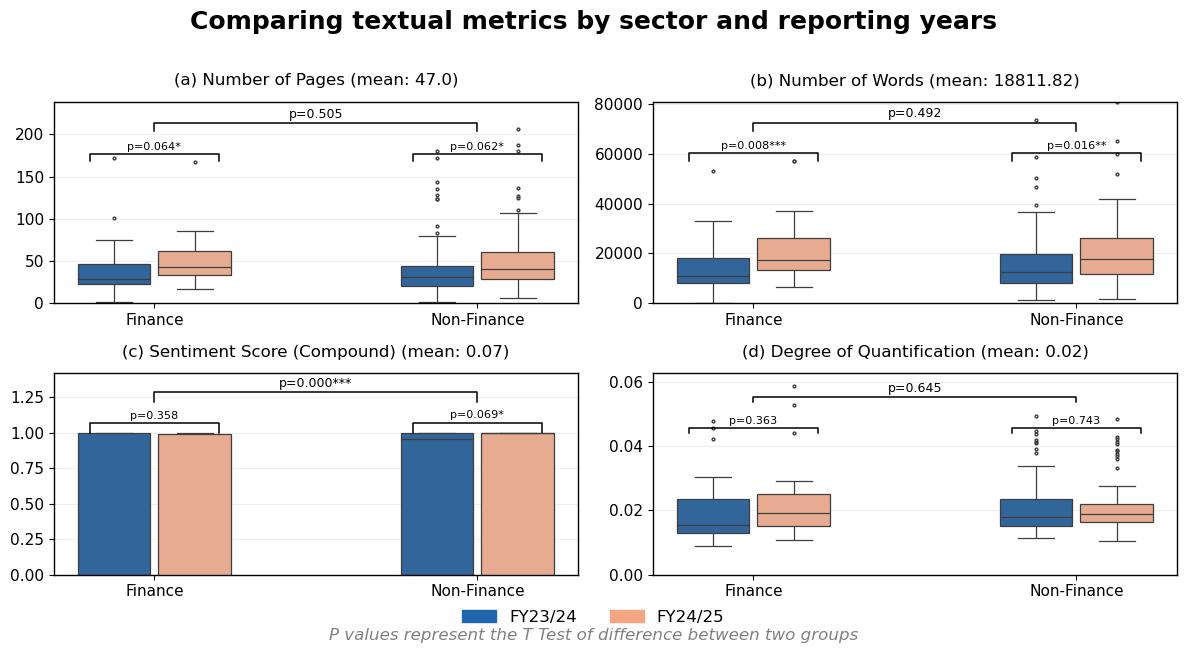

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy import stats

rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB', 'grid.linewidth': 0.6,
})
# Derive short year labels from cohort names
def cohort_short_label(name):
    match = re.search(r'\((.+?)\)', str(name))
    return match.group(1) if match else name
cohort_names = sorted(nlp_analysis['cohort'].unique())
c1_name      = cohort_names[0]  # Cohort 1 (≤ Jun 2024)
c2_name      = cohort_names[1]  # Cohort 2 (Jul 2024 – Jun 2025)
c1_label = cohort_short_label(c1_name)  # '≤ Jun 2024'
c2_label = cohort_short_label(c2_name)  # 'Jul 2024 – Jun 2025'

COHORT_LABELS = {c1_name: 'FY23/24', c2_name: 'FY24/25'}

COHORT_COLORS = {c1_name: '#2166AC', c2_name: '#F4A582'}
metric_labels = {
    'pages_num':    '(a) Number of Pages',
    'number_words': '(b) Number of Words',
    'compound':     '(c) Sentiment Score (Compound)',
    #'digits':       'Digit Count',
    #'dollars':      'Dollar Mentions',
    #'percentages':  'Percentage Mentions',
    'quantitivate_relative': '(d) Degree of Quantification'
}

def sig_label(p):
    if p < 0.01: return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

def draw_bracket(ax, x1, x2, y, p, fontsize=8):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.1, color='black')
    ax.text((x1+x2)/2, y+h*1.3, f'p={p:.3f}{sig_label(p)}',
            ha='center', va='bottom', fontsize=fontsize, fontweight='normal')

# ── Finance vs Non-Finance sector label ───────────────────────────────────────
finance_industries = ['Finance - Banks', 'Finance - Insurance', 'Finance - Other', 'Investment Schemes']
nlp_analysis['sector'] = nlp_analysis['industry'].apply(
    lambda x: 'Finance' if x in finance_industries else 'Non-Finance'
)

# ── Pre-compute all t-tests ────────────────────────────────────────────────────
ttests = {}
for metric, label in metric_labels.items():
    fin_c1  = nlp_analysis[(nlp_analysis['sector']=='Finance')     & (nlp_analysis['cohort']==c1_name)][metric].dropna()
    fin_c2  = nlp_analysis[(nlp_analysis['sector']=='Finance')     & (nlp_analysis['cohort']==c2_name)][metric].dropna()
    nfin_c1 = nlp_analysis[(nlp_analysis['sector']=='Non-Finance') & (nlp_analysis['cohort']==c1_name)][metric].dropna()
    nfin_c2 = nlp_analysis[(nlp_analysis['sector']=='Non-Finance') & (nlp_analysis['cohort']==c2_name)][metric].dropna()
    fin_all  = nlp_analysis[nlp_analysis['sector']=='Finance'][metric].dropna()
    nfin_all = nlp_analysis[nlp_analysis['sector']=='Non-Finance'][metric].dropna()
    ttests[metric] = {
        'fin_cohort':  stats.ttest_ind(fin_c1,  fin_c2).pvalue  if len(fin_c1)>1  and len(fin_c2)>1  else 1,
        'nfin_cohort': stats.ttest_ind(nfin_c1, nfin_c2).pvalue if len(nfin_c1)>1 and len(nfin_c2)>1 else 1,
        'sector':      stats.ttest_ind(fin_all,  nfin_all).pvalue,
    }

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 6), facecolor='white')
fig.patch.set_facecolor('white')
axes = axes.flatten()

# seaborn hue dodge offset ≈ ±0.2 for 2 groups
DODGE = 0.2

for i, (metric,label) in enumerate(metric_labels.items()):
    ax = axes[i]
    sns.boxplot(
        data=nlp_analysis,
        x='sector', y=metric, hue='cohort',
        palette=COHORT_COLORS,
        order=['Finance', 'Non-Finance'],
        hue_order=[c1_name, c2_name],
        linewidth=0.9, fliersize=2, width=0.5, gap=0.1,
        ax=ax,
    )
    ax.set_facecolor('white')
    ax.get_legend().remove()

    p_fin   = ttests[metric]['fin_cohort']
    p_nfin  = ttests[metric]['nfin_cohort']
    p_sec   = ttests[metric]['sector']

    ymax  = nlp_analysis[metric].quantile(0.97)
    step  = ymax * 0.12

    # Bracket: Finance C1 vs C2
    draw_bracket(ax, 0-DODGE, 0+DODGE, ymax,          p_fin)
    # Bracket: Non-Finance C1 vs C2
    draw_bracket(ax, 1-DODGE, 1+DODGE, ymax,          p_nfin)
    # Bracket: Finance vs Non-Finance (higher)
    draw_bracket(ax, 0,       1,       ymax + step*1.8, p_sec, fontsize=9)

    ax.set_ylim(0, ymax + step * 3.5)
    ax.set_title(f'{metric_labels[metric]} (mean: {round(nlp_analysis[metric].mean(),2)})',
                  pad=12,fontweight='normal')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

# Shared legend
# In the shared legend block, replace:
patches = [mpatches.Patch(color=COHORT_COLORS[c], label=COHORT_LABELS[c])
           for c in [c1_name, c2_name]]
fig.legend(handles=patches, title='',
           loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=12)


fig.suptitle('Comparing textual metrics by sector and reporting years', fontsize=18, fontweight='bold', y=1.01)
fig.text(0.5, -0.04, 'P values represent the T Test of difference between two groups',
         ha='center', fontsize=12, color='grey', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER, 'Fig05_boxplot_sector_cohort_combined.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
